<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homework61.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prac 06.1

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [16]:
import cv2
import dlib
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [17]:
!wget https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic61_1.jpg
!wget https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic61_2.jpg

--2026-05-19 11:17:19--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic61_1.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46287 (45K) [image/jpeg]
Saving to: ‘pic61_1.jpg.2’

pic61_1.jpg.2       100%[===================>]  45.20K  --.-KB/s    in 0.01s   

2026-05-19 11:17:19 (4.10 MB/s) - ‘pic61_1.jpg.2’ saved [46287/46287]

--2026-05-19 11:17:19--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic61_2.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 153408 (150K) [image/jpeg]
Saving to: ‘

### Step 1

Load an image (any image that contains faces).

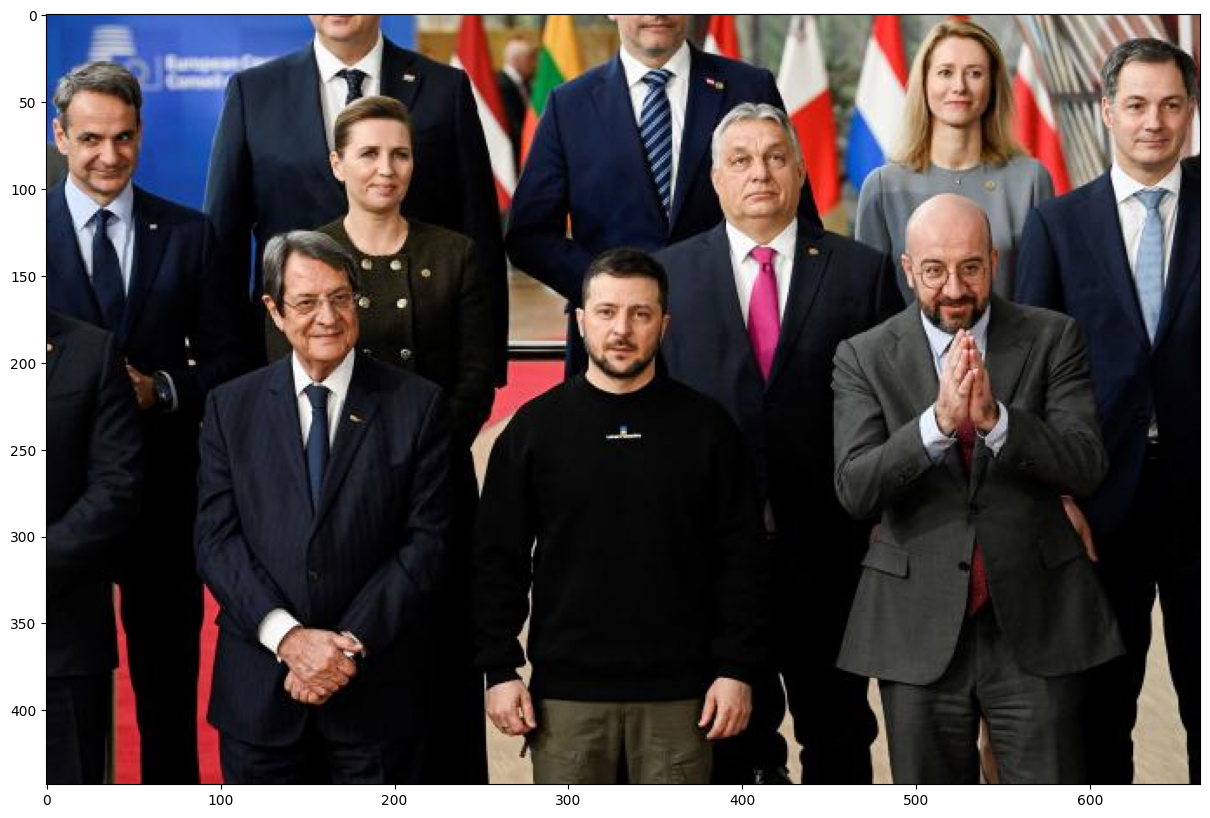

In [18]:
img = cv2.imread('pic61_1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### Step 2

Load the dlib face predictor.

In [19]:
detector = dlib.get_frontal_face_detector()

### Step 3

Run the predictor on your image.

In [20]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
detections = detector(img_gray, 1)
print(f'Знайдено облич: {len(detections)}')

Знайдено облич: 8


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

(np.float64(-0.5), np.float64(663.5), np.float64(442.5), np.float64(-0.5))

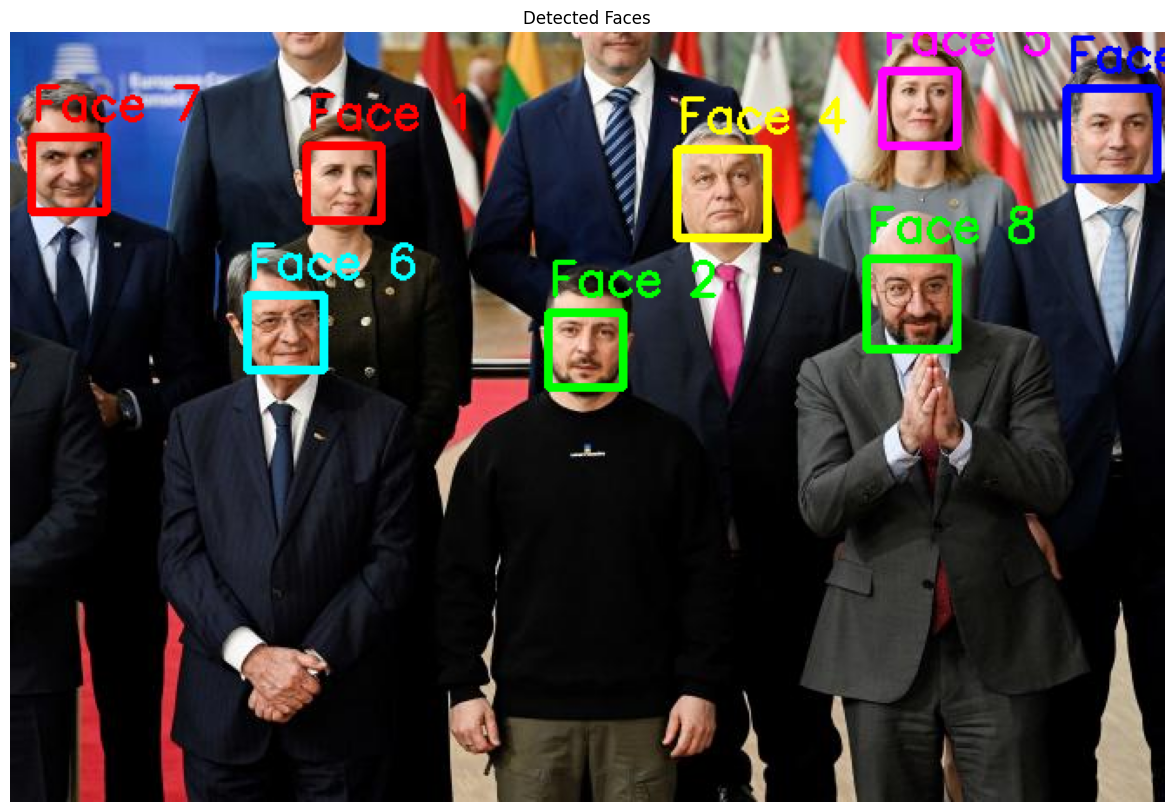

In [21]:
colors = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255),
    (255, 255, 0), (255, 0, 255), (0, 255, 255)
]

result = np.copy(img)
for i, det in enumerate(detections):
    color = colors[i % len(colors)]
    x1, y1, x2, y2 = det.left(), det.top(), det.right(), det.bottom()
    cv2.rectangle(result, (x1, y1), (x2, y2), color, 3)
    cv2.putText(result, f'Face {i+1}', (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

plt.imshow(result)
plt.title('Detected Faces')
plt.axis('off')

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

Знайдено облич: 3


(<Axes: title={'center': 'Detected Faces (hard)'}>,
 Text(0.5, 1.0, 'Detected Faces (hard)'))

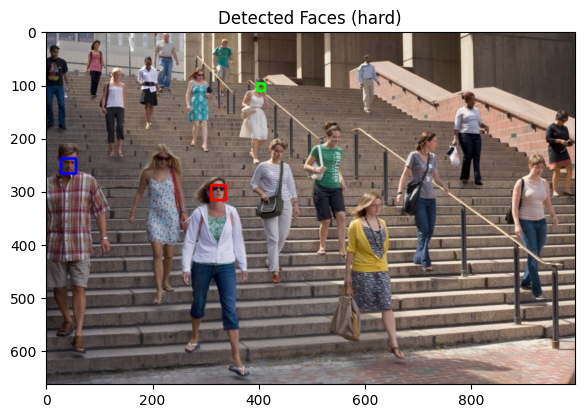

In [26]:
img2 = cv2.imread('pic61_2.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

detections2 = detector(img2_gray, 4)
print(f'Знайдено облич: {len(detections2)}')

result2 = np.copy(img2)
for i, det in enumerate(detections2):
    color = colors[i % len(colors)]
    x1, y1, x2, y2 = det.left(), det.top(), det.right(), det.bottom()
    cv2.rectangle(result2, (x1, y1), (x2, y2), color, 3)

plt.subplot(122), plt.imshow(result2), plt.title('Detected Faces (hard)')

On the challenging image, the detector found just a few faces.
This happens because the faces are small, some are turned sideways, and the image contains complex background and lighting conditions.
Therefore, the detector is not fully robust for difficult real-world scenes.